# Quantitative MRI T2 Mapping

**Goal:** Estimate per-pixel T2 relaxation time maps from multi-echo spin-echo MRI data.

**Forward model:** At each pixel, the signal at echo time $TE_n$ follows mono-exponential decay:

$$S(TE_n) = M_0 \cdot \exp\!\left(-\frac{TE_n}{T_2}\right)$$

where $M_0$ is the proton density (equilibrium magnetization) and $T_2$ is the transverse relaxation time in milliseconds.

**Inverse problem:** Given noisy multi-echo measurements $\{S(TE_n)\}_{n=1}^{N}$, estimate $T_2$ and $M_0$ at every pixel.

**Noise model:** Magnitude MRI has Rician noise: $S_\text{noisy} = |S_\text{clean} + \eta|$ where $\eta \sim \mathcal{CN}(0, \sigma^2)$.

This notebook loads precomputed results and visualizes the T2 mapping pipeline.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Add task root to path
TASK_DIR = os.path.dirname(os.getcwd())
sys.path.insert(0, TASK_DIR)

from src.preprocessing import load_multi_echo_data, load_ground_truth, load_metadata, preprocess_signal
from src.visualization import compute_ncc, compute_nrmse

## 1. Load Data and Ground Truth

The synthetic dataset is a modified Shepp-Logan phantom with T2 values assigned per tissue region:
- Bone/scalp: 40 ms
- White matter: 70 ms
- Gray matter: 80 ms
- Deep gray matter: 120 ms
- CSF/bright tissue: 150 ms

Multi-echo data was simulated at 10 echo times (10 to 100 ms) with Rician noise ($\sigma = 0.02$).

In [2]:
# Load data
signal = load_multi_echo_data(TASK_DIR)
T2_gt, M0_gt, tissue_mask = load_ground_truth(TASK_DIR)
meta = load_metadata(TASK_DIR)
TE = meta['echo_times_ms']

signal_2d = preprocess_signal(signal)
T2_gt_2d = T2_gt[0]
M0_gt_2d = M0_gt[0]
mask_2d = tissue_mask[0]

print(f"Signal shape: {signal.shape}")
print(f"Echo times: {TE} ms")
print(f"Tissue pixels: {mask_2d.sum()} / {mask_2d.size}")
print(f"Noise sigma: {meta['noise_sigma']}")

Signal shape: (1, 256, 256, 10)
Echo times: [ 10.  20.  30.  40.  50.  60.  70.  80.  90. 100.] ms
Tissue pixels: 27817 / 65536
Noise sigma: 0.02


## 2. Ground Truth T2 and M0 Maps

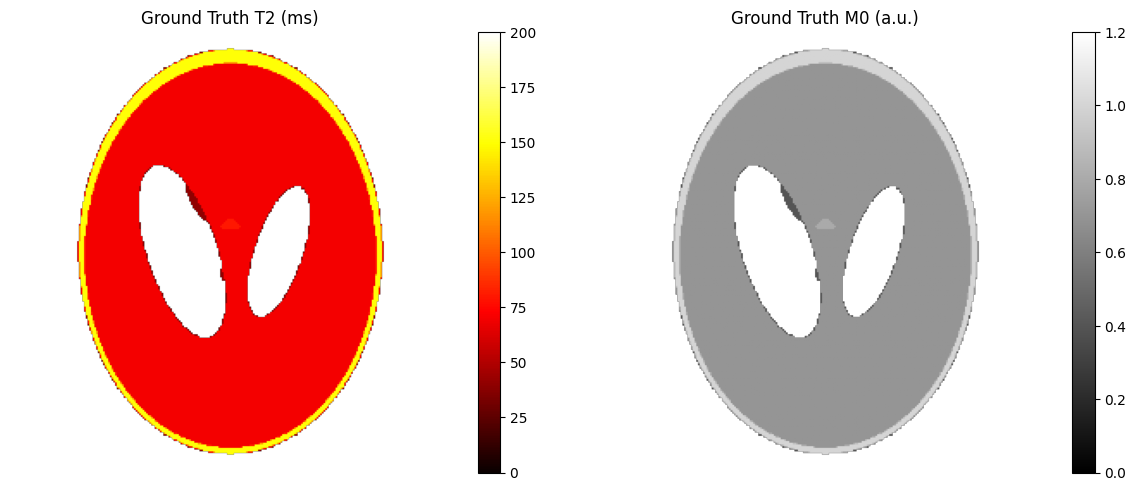

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

T2_disp = np.where(mask_2d, T2_gt_2d, np.nan)
M0_disp = np.where(mask_2d, M0_gt_2d, np.nan)

im0 = axes[0].imshow(T2_disp, vmin=0, vmax=200, cmap='hot')
axes[0].set_title('Ground Truth T2 (ms)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(M0_disp, vmin=0, vmax=1.2, cmap='gray')
axes[1].set_title('Ground Truth M0 (a.u.)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.show()

## 3. Multi-Echo Signal Examples

Each pixel has a signal that decays exponentially with echo time. Below we show decay curves at representative tissue locations.

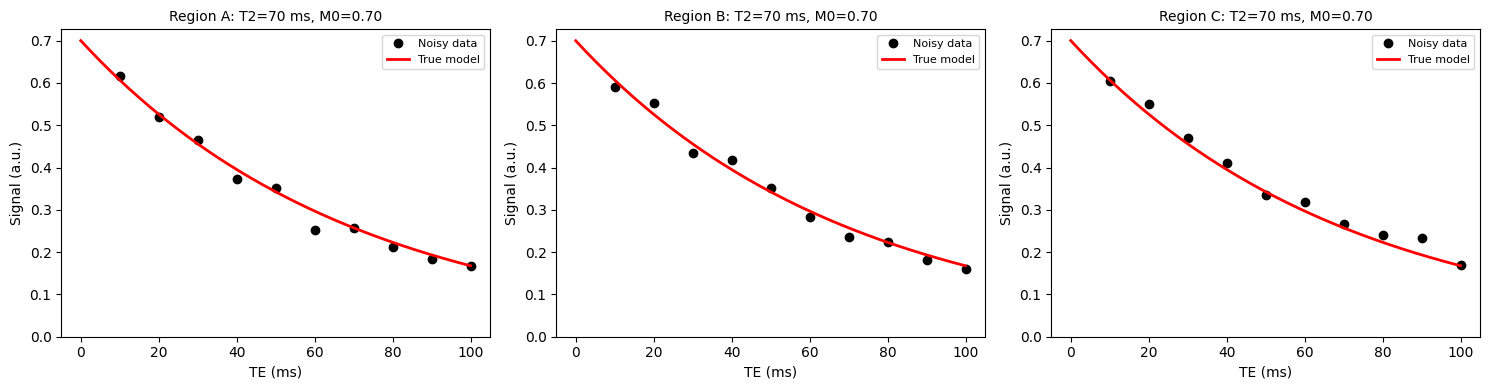

In [4]:
# Find representative pixels with different T2 values
cy, cx = 128, 128
pixel_coords = []
pixel_labels = []
for dy, dx, label in [(-30, 0, "Region A"), (0, 0, "Region B"), (30, 0, "Region C"), (0, 40, "Region D")]:
    py, px = cy + dy, cx + dx
    if mask_2d[py, px]:
        pixel_coords.append((py, px))
        pixel_labels.append(f"{label}: T2={T2_gt_2d[py,px]:.0f} ms, M0={M0_gt_2d[py,px]:.2f}")

fig, axes = plt.subplots(1, len(pixel_coords), figsize=(5 * len(pixel_coords), 4))
TE_fine = np.linspace(0, TE[-1], 200)

for i, ((y, x), label) in enumerate(zip(pixel_coords, pixel_labels)):
    s = signal_2d[y, x, :]
    t2 = T2_gt_2d[y, x]
    m0 = M0_gt_2d[y, x]
    
    axes[i].plot(TE, s, 'ko', markersize=6, label='Noisy data')
    axes[i].plot(TE_fine, m0 * np.exp(-TE_fine / t2), 'r-', linewidth=2, label='True model')
    axes[i].set_xlabel('TE (ms)')
    axes[i].set_ylabel('Signal (a.u.)')
    axes[i].set_title(label, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 4. Precomputed T2 Maps

We load precomputed T2 maps from two fitting methods:
1. **Log-linear fit**: Linearize via $\log S = \log M_0 - TE/T_2$ and solve by ordinary least squares. Fast but biased by Rician noise.
2. **Nonlinear least-squares**: Directly fit $S = M_0 \exp(-TE/T_2)$ per pixel using Levenberg-Marquardt, initialized from the log-linear estimate.

In [5]:
# Load precomputed reference outputs
ref_dir = os.path.join(TASK_DIR, 'evaluation', 'reference_outputs')

ll_data = np.load(os.path.join(ref_dir, 'T2_map_loglinear.npz'))
T2_ll = ll_data['T2_map'][0].astype(np.float64)
M0_ll = ll_data['M0_map'][0].astype(np.float64)

nls_data = np.load(os.path.join(ref_dir, 'T2_map_nonlinear.npz'))
T2_nls = nls_data['T2_map'][0].astype(np.float64)
M0_nls = nls_data['M0_map'][0].astype(np.float64)

print("Loaded precomputed T2 maps.")
print(f"  Log-linear T2 range (tissue): [{T2_ll[mask_2d].min():.1f}, {T2_ll[mask_2d].max():.1f}] ms")
print(f"  Nonlinear LS T2 range (tissue): [{T2_nls[mask_2d].min():.1f}, {T2_nls[mask_2d].max():.1f}] ms")

Loaded precomputed T2 maps.
  Log-linear T2 range (tissue): [19.5, 187.8] ms
  Nonlinear LS T2 range (tissue): [32.1, 182.4] ms


### Log-Linear T2 Map vs Ground Truth

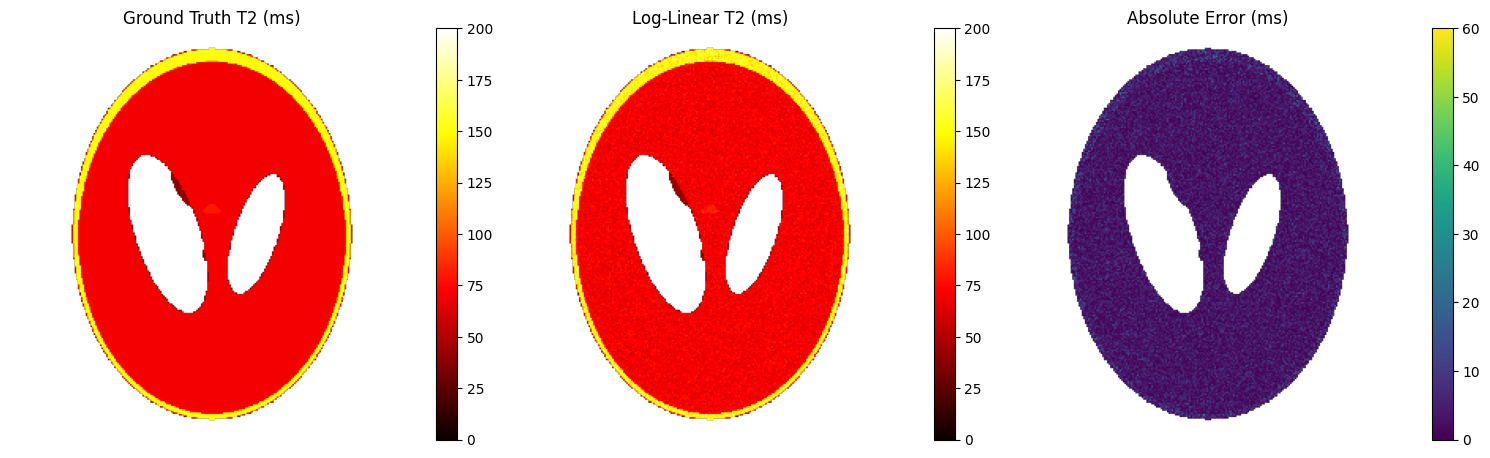

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vmin, vmax = 0, 200

T2_gt_disp = np.where(mask_2d, T2_gt_2d, np.nan)
T2_ll_disp = np.where(mask_2d, T2_ll, np.nan)
error_ll = np.where(mask_2d, np.abs(T2_ll - T2_gt_2d), np.nan)

im0 = axes[0].imshow(T2_gt_disp, vmin=vmin, vmax=vmax, cmap='hot')
axes[0].set_title('Ground Truth T2 (ms)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(T2_ll_disp, vmin=vmin, vmax=vmax, cmap='hot')
axes[1].set_title('Log-Linear T2 (ms)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(error_ll, vmin=0, vmax=60, cmap='viridis')
axes[2].set_title('Absolute Error (ms)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

### Nonlinear Least-Squares T2 Map vs Ground Truth

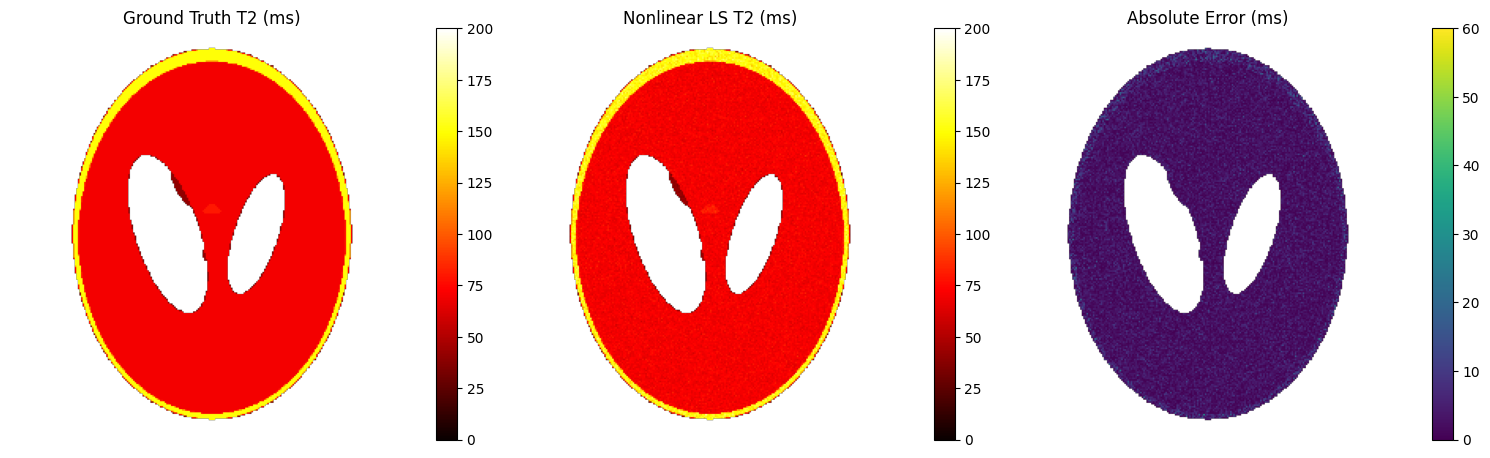

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

T2_nls_disp = np.where(mask_2d, T2_nls, np.nan)
error_nls = np.where(mask_2d, np.abs(T2_nls - T2_gt_2d), np.nan)

im0 = axes[0].imshow(T2_gt_disp, vmin=vmin, vmax=vmax, cmap='hot')
axes[0].set_title('Ground Truth T2 (ms)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(T2_nls_disp, vmin=vmin, vmax=vmax, cmap='hot')
axes[1].set_title('Nonlinear LS T2 (ms)')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

im2 = axes[2].imshow(error_nls, vmin=0, vmax=60, cmap='viridis')
axes[2].set_title('Absolute Error (ms)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.show()

## 5. Quantitative Metrics

We evaluate T2 maps using two metrics computed within the tissue mask:
- **NCC** (Normalized Cross-Correlation): cosine similarity, 1.0 is perfect
- **NRMSE** (Normalized Root Mean Square Error): normalized by dynamic range, 0.0 is perfect

In [8]:
# Compute metrics
ncc_ll = compute_ncc(T2_ll, T2_gt_2d, mask=mask_2d)
nrmse_ll = compute_nrmse(T2_ll, T2_gt_2d, mask=mask_2d)
ncc_nls = compute_ncc(T2_nls, T2_gt_2d, mask=mask_2d)
nrmse_nls = compute_nrmse(T2_nls, T2_gt_2d, mask=mask_2d)

# Load metrics boundaries
with open(os.path.join(TASK_DIR, 'evaluation', 'metrics.json')) as f:
    metrics = json.load(f)

print(f"{'Method':<30s} {'NCC':>8s} {'NRMSE':>8s}")
print("-" * 50)
print(f"{'Log-linear fit':<30s} {ncc_ll:>8.4f} {nrmse_ll:>8.4f}")
print(f"{'Nonlinear least-squares':<30s} {ncc_nls:>8.4f} {nrmse_nls:>8.4f}")
print("-" * 50)
print(f"{'Boundary (pass threshold)':<30s} {metrics['ncc_boundary']:>8.4f} {metrics['nrmse_boundary']:>8.4f}")

Method                              NCC    NRMSE
--------------------------------------------------
Log-linear fit                   0.9982   0.0444
Nonlinear least-squares          0.9988   0.0371
--------------------------------------------------
Boundary (pass threshold)        0.8989   0.0408


## 6. Signal Decay Curves with Fitted Models

Compare the noisy data points, true model, and fitted model at selected pixels.

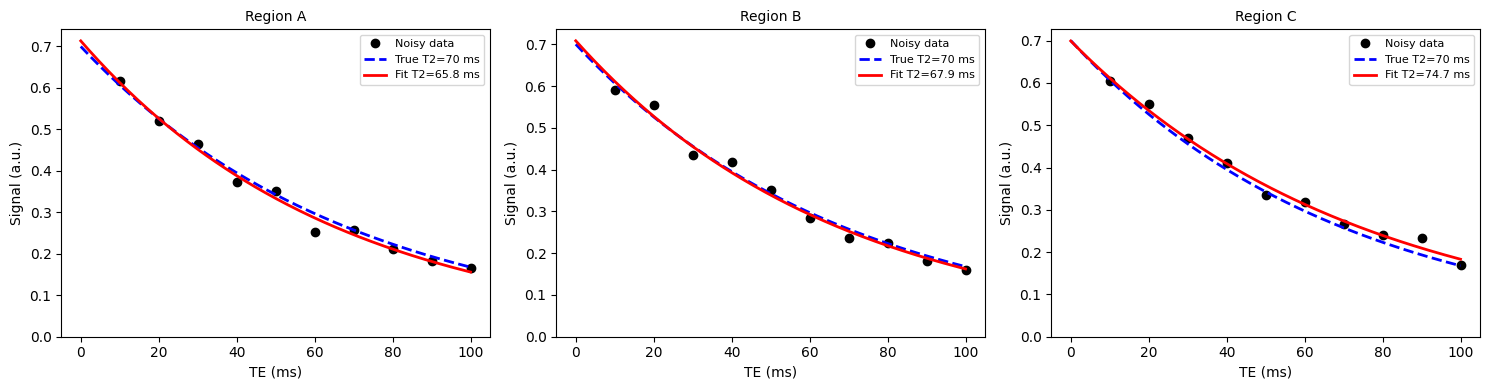

In [9]:
fig, axes = plt.subplots(1, len(pixel_coords), figsize=(5 * len(pixel_coords), 4))
TE_fine = np.linspace(0, TE[-1], 200)

for i, ((y, x), label) in enumerate(zip(pixel_coords, pixel_labels)):
    s = signal_2d[y, x, :]
    t2_true = T2_gt_2d[y, x]
    m0_true = M0_gt_2d[y, x]
    t2_fit = T2_nls[y, x]
    m0_fit = M0_nls[y, x]
    
    axes[i].plot(TE, s, 'ko', markersize=6, label='Noisy data')
    axes[i].plot(TE_fine, m0_true * np.exp(-TE_fine / t2_true),
                 'b--', linewidth=2, label=f'True T2={t2_true:.0f} ms')
    if t2_fit > 0:
        axes[i].plot(TE_fine, m0_fit * np.exp(-TE_fine / t2_fit),
                     'r-', linewidth=2, label=f'Fit T2={t2_fit:.1f} ms')
    axes[i].set_xlabel('TE (ms)')
    axes[i].set_ylabel('Signal (a.u.)')
    axes[i].set_title(label.split(':')[0], fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylim(bottom=0)

plt.tight_layout()
plt.show()

## 7. Reproduce from Scratch (Optional)

The cells below run the full fitting pipeline. They are commented out because the nonlinear fit takes a few minutes on a 256x256 image. Uncomment to reproduce.

In [10]:
# from src.solvers import fit_t2_loglinear, fit_t2_nonlinear
#
# # Log-linear fit
# T2_ll_new, M0_ll_new = fit_t2_loglinear(signal_2d, TE, mask=mask_2d)
#
# # Nonlinear least-squares fit (initialized from log-linear)
# T2_nls_new, M0_nls_new = fit_t2_nonlinear(
#     signal_2d, TE, mask=mask_2d,
#     T2_init=T2_ll_new, M0_init=M0_ll_new,
# )
#
# ncc_new = compute_ncc(T2_nls_new, T2_gt_2d, mask=mask_2d)
# nrmse_new = compute_nrmse(T2_nls_new, T2_gt_2d, mask=mask_2d)
# print(f"Nonlinear LS: NCC={ncc_new:.4f}, NRMSE={nrmse_new:.4f}")

## Conclusion

This task demonstrates quantitative MRI T2 mapping as a parameter estimation inverse problem. Key observations:

- The mono-exponential model $S = M_0 \exp(-TE/T_2)$ is a good approximation for single-component tissues
- Log-linear fitting is fast but biased; nonlinear least-squares gives more accurate T2 estimates
- Both methods achieve high NCC (>0.99) and low NRMSE (<0.05) on this synthetic phantom with moderate noise
- The main challenges in real data include: multi-component T2 decay, stimulated echoes, B1 inhomogeneity, and low SNR at long echo times